# Polynomial Regression from Scratch

Goal: predict **house price** from **house size**.

We use a degree-3 model without bias term:

$$
\hat{y} = w_1x + w_2x^2 + w_3x^3
$$

- $w_1$: linear effect of size
- $w_2$: curvature effect
- $w_3$: higher-order curvature effect

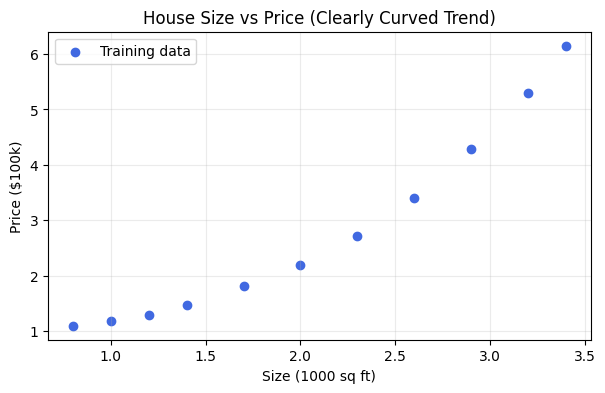

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# x: house size in 1000 sq ft, y: price in $100k
# Data is intentionally curved (nonlinear) for polynomial regression.
x = np.array([0.8, 1.0, 1.2, 1.4, 1.7, 2.0, 2.3, 2.6, 2.9, 3.2, 3.4])
y = np.array([1.10, 1.18, 1.30, 1.48, 1.82, 2.20, 2.72, 3.40, 4.28, 5.30, 6.15])

plt.figure(figsize=(7, 4))
plt.scatter(x, y, color='royalblue', label='Training data')
plt.xlabel('Size (1000 sq ft)')
plt.ylabel('Price ($100k)')
plt.title('House Size vs Price (Clearly Curved Trend)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 1) Build polynomial features

For each input $x$, create three features:

$$
[x,\ x^2,\ x^3]
$$

For all training examples, this gives a design matrix:

$$
X = \begin{bmatrix}
x^{(1)} & (x^{(1)})^2 & (x^{(1)})^3 \\
x^{(2)} & (x^{(2)})^2 & (x^{(2)})^3 \\
\vdots & \vdots & \vdots \\
x^{(m)} & (x^{(m)})^2 & (x^{(m)})^3
\end{bmatrix}
$$

Prediction for all points at once:

$$
\hat{y} = Xw
$$

In [6]:
def poly_features(x):
    return np.column_stack([x, x**2, x**3])

X = poly_features(x)
print('X shape:', X.shape)
print('First row [x, x^2, x^3]:', X[0])

X shape: (11, 3)
First row [x, x^2, x^3]: [0.8   0.64  0.512]


## 2) Cost and gradients

We measure error with Mean Squared Error:

$$
J(w) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

Vector form:

$$
J(w) = \frac{1}{2m}\|Xw - y\|^2
$$

Gradient:

$$
\nabla J(w) = \frac{1}{m}X^T(Xw - y)
$$

Gradient descent update:

$$
w \leftarrow w - \alpha\nabla J(w)
$$

- $m$: number of training examples
- $\alpha$: learning rate

In [7]:
def compute_cost(X, y, w):
    m = len(y)
    y_hat = X @ w
    return (1 / (2 * m)) * np.sum((y_hat - y) ** 2)


def gradient_descent(X, y, w_init, alpha=1e-4, iters=50000):
    m = len(y)
    w = w_init.astype(float).copy()
    history = []

    for _ in range(iters):
        y_hat = X @ w
        grad = (1 / m) * (X.T @ (y_hat - y))
        w -= alpha * grad
        history.append(compute_cost(X, y, w))

    return w, history

## 3) Train and visualize

Steps:
1. Initialize $w = [0,0,0]$
2. Run gradient descent with a small learning rate
3. Plot the learned polynomial curve
4. Plot cost vs. iteration

The cost curve should go down if learning is working properly.

Learned weights [w1, w2, w3]: [0.5106 0.2863 0.0218]
Final cost: 0.030529


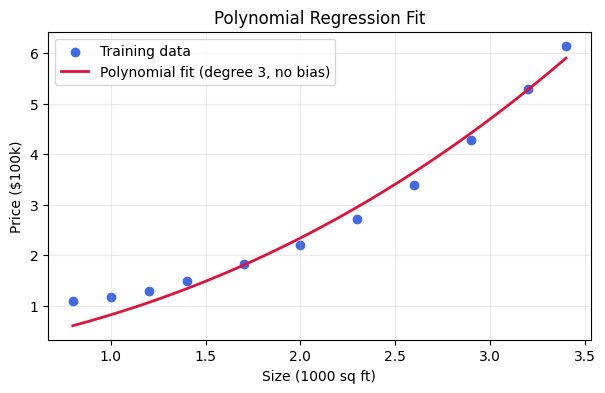

In [ ]:
w0 = np.zeros(X.shape[1])
# Small learning rate keeps training stable with polynomial terms.
w, history = gradient_descent(X, y, w0, alpha=1e-4, iters=50000)

print('Learned weights [w1, w2, w3]:', np.round(w, 4))
print('Final cost:', round(history[-1], 6))

# Smooth curve for plotting
x_line = np.linspace(x.min(), x.max(), 200)
X_line = poly_features(x_line)
y_line = X_line @ w

plt.figure(figsize=(7, 4))
plt.scatter(x, y, color='royalblue', label='Training data')
plt.plot(x_line, y_line, color='crimson', linewidth=2, label='Polynomial fit (degree 3, no bias)')
plt.xlabel('Size (1000 sq ft)')
plt.ylabel('Price ($100k)')
plt.title('Polynomial Regression Fit')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(history, color='darkgreen')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w)')
plt.title('Cost Decreases During Gradient Descent')
plt.grid(alpha=0.25)
plt.show()

## Quick recap

- Converted each input into $[x, x^2, x^3]$
- Predicted with $\hat{y}=Xw$
- Minimized MSE using gradient descent
- Learned a curved fit that matches the trend better than a straight line